## Multi-Concept Top-k Concept Guided Decoding

Comparison of three generation modes:
- **No steering** (baseline): standard greedy generation.
- **Single-concept steering**: existing CGD with one concept pair (A − B).
- **Multi-concept steering**: two concept pairs composed via `linear` or `subspace` fusion.

In [1]:
import pandas as pd

from frames.representations import FrameUnembeddingRepresentation
from frames.nlp.datasets import load_multilingual_question_dataset
from frames.utils.plotting import lineplot_and_save

In [2]:
# parameters
MODEL_ID = "hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4"
N = 256
STEPS = 32
BATCH_SIZE = 16
K = 3
MIN_LEMMAS = 3
MAX_TOKENS = 3

# concept pairs: each (A, B) produces a directional guide A − B
CONCEPT_PAIRS = [
    ("woman.n.01", "man.n.01"),
    ("science.n.01", "art.n.01"),
]

MODES = ["linear", "subspace"]

# weight sweep for linear mode: (weight_pair_0, weight_pair_1)
WEIGHTS_SWEEP = [(1.0, 0.0), (0.7, 0.3), (0.5, 0.5), (0.3, 0.7), (0.0, 1.0)]

X = "token index"
Y = "total projection"
HUE = "condition"

In [3]:
fur = FrameUnembeddingRepresentation.from_model_id(MODEL_ID)

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


/home/rodrigo/projects/frame-representation-hypothesis/.venv/lib/python3.11/site-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

2026-06-22 21:06:11.696 | INFO     | frames.models.hf.base:__init__:88 - Loaded model: hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4
2026-06-22 21:06:11.699 | WARNING  | frames.models.hf.base:__init__:89 - memory cost: 5462 Mb


In [4]:
dataset = load_multilingual_question_dataset(fur.data.languages).iloc[:N]
inputs = dataset["English"].tolist()
print("Loaded", len(inputs), "inputs")

Loaded 256 inputs


In [5]:
inputs = [
    "<|start_header_id|>user<|end_header_id|>What men can be?<|eot_id|><|start_header_id|>assistant<|end_header_id|>1.",
    "<|start_header_id|>user<|end_header_id|>What women can be?<|eot_id|><|start_header_id|>assistant<|end_header_id|>1.",
]

### Section A — No steering (baseline)

Standard autoregressive generation, no concept guidance.

In [6]:
baseline_texts = fur.generate(inputs, max_new_tokens=STEPS, batch_size=BATCH_SIZE)
print("Example (no steering):", baseline_texts[0])

100%|██████████| 1/1 [00:02<00:00,  2.50s/it]

Example (no steering): <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can be a father, a husband, a son, a brother, a friend, a neighbor, a colleague, a boss, a leader, a


### Section B — Single-concept steering

Existing CGD: steer toward each concept pair individually.

In [11]:
single_results = {}  # (synset_a, synset_b) -> (texts, probe)

for pair in CONCEPT_PAIRS:
    label = f"{pair[0]} - {pair[1]}"
    print(f"Running single-concept: {label}")
    texts, probe = fur.quick_generate_with_topk_guide(
        inputs,
        guide=pair,
        k=K,
        steps=STEPS,
        batch_size=BATCH_SIZE,
        min_lemmas_per_synset=MIN_LEMMAS,
        max_token_count=MAX_TOKENS,
    )
    single_results[pair] = (texts, probe)
    print(f"  example: {texts[0]}")

Running single-concept: woman.n.01 - man.n.01


100%|██████████| 1/1 [00:05<00:00,  5.82s/it]


  example: <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4-
Running single-concept: science.n.01 - art.n.01


100%|██████████| 1/1 [00:05<00:00,  5.82s/it]

  example: <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A husband
A father 
A brother 
A friend 
2\. A teacher 
3\. Men can work 
A businessman
A farmer 
A teacher 
4


In [12]:
# build probe DataFrame for single-concept runs
dfs_single = []
for pair, (_, probe) in single_results.items():
    label = f"{pair[0]} - {pair[1]}"
    df = pd.DataFrame(probe.numpy()).melt(var_name=X, value_name=Y)
    df[HUE] = f"single: {label}"
    dfs_single.append(df)

df_single = pd.concat(dfs_single, ignore_index=True)

### Section C — Multi-concept steering (linear and subspace)

Both concept pairs are composed into a single guide using `compose_concepts`.

In [ ]:
multi_results = {}  # mode -> (texts, probe, per_concept_dict)

texts, probe, per_concept = fur.generate_with_multi_topk_guide(
    inputs,
    guides=CONCEPT_PAIRS,
    k=K,
    steps=STEPS,
    batch_size=BATCH_SIZE,
)
multi_results = (texts, probe, per_concept)
print(f"  example: {texts[0]}")

  0%|          | 0/1 [00:00<?, ?it/s]


AttributeError: 'tuple' object has no attribute 'device'

In [14]:
# build combined probe DataFrame (multi-concept composed guide alignment)
dfs_multi = []
for mode, (_, probe, _) in multi_results.items():
    df = pd.DataFrame(probe.numpy()).melt(var_name=X, value_name=Y)
    df[HUE] = f"multi [{mode}]"
    dfs_multi.append(df)

df_multi = pd.concat(dfs_multi, ignore_index=True)

### Section D — Weight sweep (linear mode)

Vary per-concept weights to check controllability of the linear composition.

In [17]:
dfs_sweep = []

for w0, w1 in WEIGHTS_SWEEP:
    label = f"w=({w0:.1f}, {w1:.1f})"
    print(f"Running weight sweep: {label}")
    texts, probe, per_concept = fur.generate_with_multi_concept_guide(
        inputs,
        guides=CONCEPT_PAIRS,
        weights=[w0, w1],
        mode="linear",
        k=K,
        steps=STEPS,
        batch_size=BATCH_SIZE,
        min_lemmas_per_synset=MIN_LEMMAS,
        max_token_count=MAX_TOKENS,
    )
    for concept_label, proj in per_concept.items():
        df = pd.DataFrame({"alignment": proj.sum(-1).detach().numpy()})
        df["concept"] = concept_label
        df["weights"] = label
        df["w0"] = w0
        dfs_sweep.append(df)

df_sweep = pd.concat(dfs_sweep, ignore_index=True)

Running weight sweep: w=(1.0, 0.0)


100%|██████████| 1/1 [00:05<00:00,  5.89s/it]


Running weight sweep: w=(0.7, 0.3)


100%|██████████| 1/1 [00:05<00:00,  5.92s/it]


Running weight sweep: w=(0.5, 0.5)


100%|██████████| 1/1 [00:05<00:00,  5.94s/it]


Running weight sweep: w=(0.3, 0.7)


100%|██████████| 1/1 [00:05<00:00,  5.99s/it]


Running weight sweep: w=(0.0, 1.0)


100%|██████████| 1/1 [00:06<00:00,  6.02s/it]


### Section E — Comparison plots

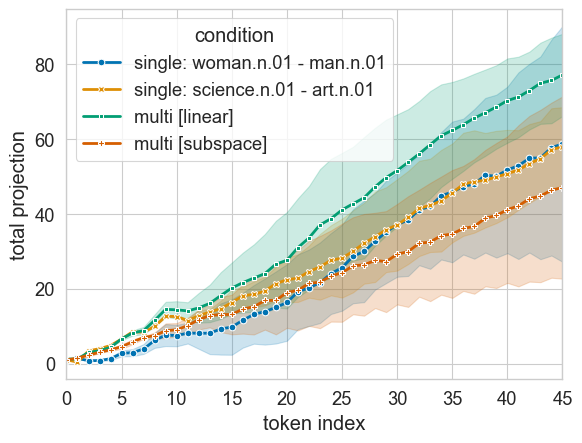

In [18]:
# combined probe: single-concept vs multi-concept modes
df_compare = pd.concat([df_single, df_multi], ignore_index=True)
lineplot_and_save("12_combined_probe", df_compare, x=X, y=Y, hue=HUE)

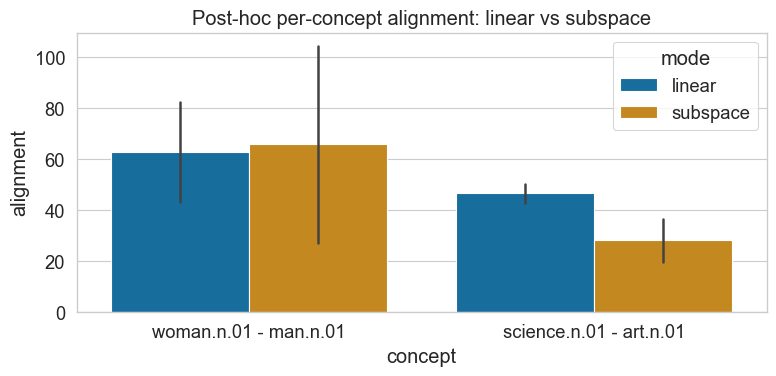

In [19]:
# per-concept post-hoc alignment: compare linear vs subspace
import seaborn as sns
import matplotlib.pyplot as plt

dfs_pc = []
for mode, (_, _, per_concept) in multi_results.items():
    for concept_label, proj in per_concept.items():
        df = pd.DataFrame({"alignment": proj.sum(-1).detach().numpy()})
        df["concept"] = concept_label
        df["mode"] = mode
        dfs_pc.append(df)

df_pc = pd.concat(dfs_pc, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(df_pc, x="concept", y="alignment", hue="mode", palette="colorblind", ax=ax)
ax.set_title("Post-hoc per-concept alignment: linear vs subspace")
plt.tight_layout()
plt.savefig("resources/12_per_concept_alignment.png", dpi=150)
plt.show()

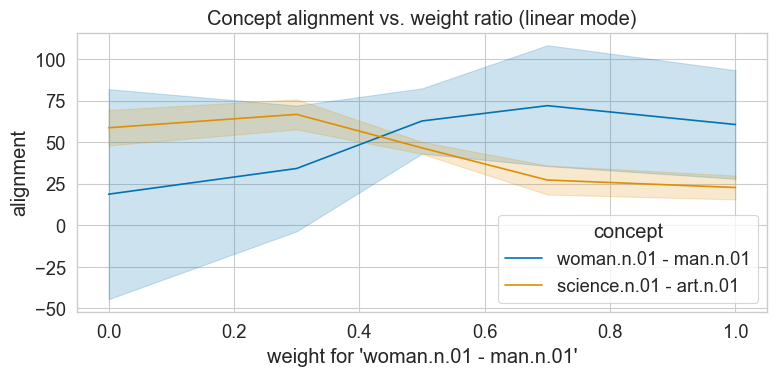

In [20]:
# weight sweep: per-concept alignment vs weight ratio
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    df_sweep,
    x="w0",
    y="alignment",
    hue="concept",
    palette="colorblind",
    markers=True,
    ax=ax,
)
ax.set_xlabel(f"weight for '{CONCEPT_PAIRS[0][0]} - {CONCEPT_PAIRS[0][1]}'")
ax.set_title("Concept alignment vs. weight ratio (linear mode)")
plt.tight_layout()
plt.savefig("resources/12_weight_sweep.png", dpi=150)
plt.show()

In [21]:
# regression check: compose_concepts with a single concept must match passing it directly
import torch

c0 = fur.get_concept(CONCEPT_PAIRS[0][0], MIN_LEMMAS, MAX_TOKENS)
c1 = fur.get_concept(CONCEPT_PAIRS[0][1], MIN_LEMMAS, MAX_TOKENS)
single_dir = c0 - c1
composed_single = fur.compose_concepts([single_dir], mode="linear")
print("Single-concept regression check (should be close to 1.0):",
      (single_dir * composed_single).item())

Single-concept regression check (should be close to 1.0): 1.0


In [24]:
# qualitative sample comparison
n_show = 5
print("=== No steering ===")
for t in baseline_texts[:n_show]:
    print(" -", t)

for pair, (texts, _) in single_results.items():
    print(f"\n=== Single: {pair[0]} - {pair[1]} ===")
    for t in texts[:n_show]:
        print(" -", t)

for mode, (texts, _, _) in multi_results.items():
    print(f"\n=== Multi [{mode}] ===")
    for t in texts[:n_show]:
        print(" -", t)

=== No steering ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. Leaders: Men can be leaders in various fields, such as politics, business, education, and community organizations. They can inspire and motivate others, make tough decisions
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. Women can be mothers. They can be mothers to their biological children, step-children, adopted children, or foster children. They can also be mothers to other

=== Single: woman.n.01 - man.n.01 ===
 - <|start_header_id|>user<|end_header_id|>What men can be?<|start_header_id|>assistant<|end_header_id|>1. A man can make you feel like a queen, and treat her like a goddess.

1-1-1-4-4-4-4-4-
 - <|start_header_id|>user<|end_header_id|>What women can be?<|start_header_id|>assistant<|end_header_id|>1. A woman is the one, the very essence, the embodiment, the personified, the feminine, the d